<a href="https://colab.research.google.com/github/emilheroyt/Bachelor-Thesis-Stress-Testing-Robustness-of-SOTA-Point-Trackers/blob/main/Blur_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Zelle 1 – Die Blur-Funktion:

In [ ]:
import numpy as np

def apply_motion_blur(frames, center_idx, window_size, gamma=2.2):
    """
    Motion Blur nach Gleichung 2 aus Chen et al. 2025 (arXiv:2503.17358):
    Mittelung erfolgt im linearen Radiometrie-Raum, nicht im Bildraum.

    frames: (T, H, W, 3) uint8 Array, Sequenz scharfer Frames
    center_idx: Index des zu verwischenden Frames
    window_size: Anzahl gemittelter Frames (ungerade, z.B. 1=kein Blur, 3, 5, 7)
    """
    half = window_size // 2
    start = max(0, center_idx - half)
    end = min(len(frames), center_idx + half + 1)
    window = frames[start:end].astype(np.float32) / 255.0

    linear = window ** gamma          # g^-1: zurück in den linearen Raum
    linear_avg = linear.mean(axis=0)  # Mittelung im linearen Raum
    blurred = linear_avg ** (1.0 / gamma)  # g: zurück in den Bildraum

    return (blurred * 255).astype(np.uint8)

def blur_video(frames, window_size):
    """Wendet den Blur auf jedes Frame eines Videos an."""
    return np.stack([apply_motion_blur(frames, i, window_size) for i in range(len(frames))])

BLUR_LEVELS = {"none": 1, "medium": 3, "strong": 7}

Zelle 2 – Auf einem Testvideo anwenden und visuell prüfen:

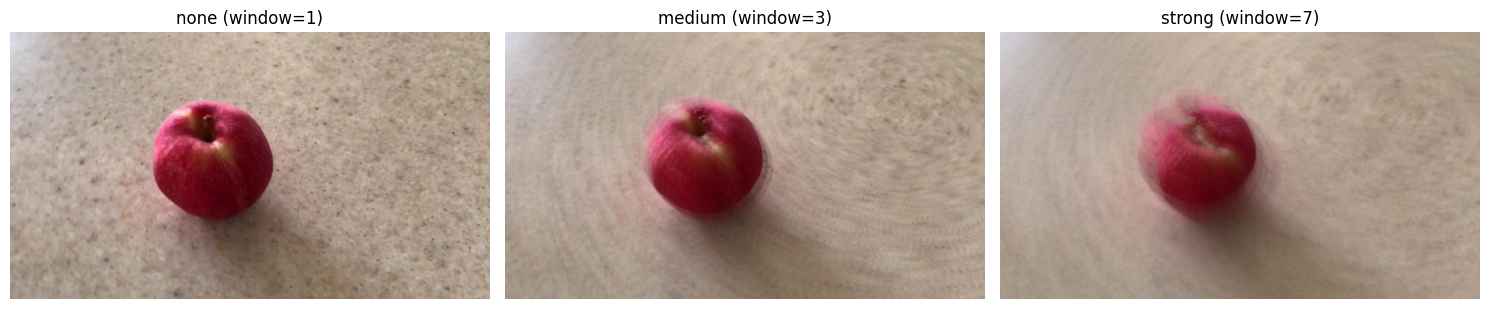

In [ ]:
import imageio.v3 as iio
import matplotlib.pyplot as plt

# Testvideo laden (das Apple-Beispiel von vorhin, oder ersetz die URL durch ein TAP-Vid-DAVIS-Video)
url = 'https://github.com/facebookresearch/co-tracker/raw/refs/heads/main/assets/apple.mp4'
frames = iio.imread(url, plugin="FFMPEG")

test_frame_idx = 15  # ein Frame irgendwo in der Mitte, wo genug Nachbar-Frames existieren

fig, axes = plt.subplots(1, len(BLUR_LEVELS), figsize=(15, 5))
for ax, (name, window) in zip(axes, BLUR_LEVELS.items()):
    blurred = apply_motion_blur(frames, test_frame_idx, window)
    ax.imshow(blurred)
    ax.set_title(f"{name} (window={window})")
    ax.axis("off")
plt.tight_layout()
plt.savefig("blur_test.png", dpi=100)
plt.show()